# **Modeling : Predicting Employee Attrition**

### **Import Libraries**

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay,
        roc_auc_score,roc_curve,average_precision_score)

RANDOM_STATE = 42

### **Load Processed Dataset**

In [3]:
df= pd.read_csv(r"../data/HR-Employee-Attrition_cleaned.csv")
df.shape

(1470, 31)

### **Feature Groups**

In [4]:
ordinal_cols = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'PerformanceRating',
    'RelationshipSatisfaction', 'WorkLifeBalance']

cat_cols = ['BusinessTravel', 'Department', 'EducationField',
            'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

num_cols = [col for col in df.select_dtypes(include=[np.number]).columns
            if col not in ordinal_cols and col != 'Attrition']

print(f"Numerical Features : {num_cols}\n")
print(f"Ordinal Features : {ordinal_cols}\n")
print(f"Categorical Features : {cat_cols}")

Numerical Features : ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Ordinal Features : ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance']

Categorical Features : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


### **Encode Target**
`Attrition`: Yes -> 1, No -> 0

In [5]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Attrition'].value_counts(normalize=True).round(3)

Attrition
0    0.839
1    0.161
Name: proportion, dtype: float64

### **Train / Test Split**
Stratified split to preserve the 84/16 class ratio in both sets.

In [6]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((1176, 30), (294, 30))

## **Baseline: Logistic Regression**

EDA showed `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager` and `YearsSinceLastPromotion`
are strongly correlated with each other and with `TotalWorkingYears`. For the linear model we drop the
most redundant three and keep `TotalWorkingYears` and `YearsAtCompany`, to reduce multicollinearity.

In [7]:
linear_drop_cols = ['YearsInCurrentRole', 'YearsWithCurrManager', 'YearsSinceLastPromotion']

num_cols_linear = [c for c in num_cols if c not in linear_drop_cols]

preprocess_linear = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_linear),
    ('ord', StandardScaler(), ordinal_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

log_reg = Pipeline(steps=[
    ('preprocess', preprocess_linear),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

X_train_lr = X_train.drop(columns=linear_drop_cols)
X_test_lr = X_test.drop(columns=linear_drop_cols)

log_reg.fit(X_train_lr, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['Age','BusinessTravel','DailyRate',...,'TrainingTimesLastYear', 'WorkLifeBalance','YearsAtCompany']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

### **Random Forest**


In [8]:
preprocess_tree = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('ord', 'passthrough', ordinal_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

rf = Pipeline(steps=[
    ('preprocess', preprocess_tree),
    ('model', RandomForestClassifier(
        n_estimators=400, max_depth=None, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1))
])

rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

## **Evaluation**
Accuracy alone is misleading on an 84/16 split, so we lean on ROC-AUC, PR-AUC, and recall/F1 for the
minority "Yes" (attrition) class.

In [9]:
def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc = average_precision_score(y_te, y_proba)

    print(f"===== {name} =====")
    print(classification_report(y_te, y_pred, target_names=['Stayed', 'Left']))
    print(f"ROC-AUC : {roc_auc:.3f}")
    print(f"PR-AUC  : {pr_auc:.3f}\n")

    return {'model': name, 'roc_auc': roc_auc, 'pr_auc': pr_auc}

results = []
results.append(evaluate("Logistic Regression", log_reg, X_test_lr, y_test))
results.append(evaluate("Random Forest", rf, X_test, y_test))

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
results_df

===== Logistic Regression =====
              precision    recall  f1-score   support

      Stayed       0.92      0.81      0.86       247
        Left       0.39      0.64      0.48        47

    accuracy                           0.78       294
   macro avg       0.66      0.72      0.67       294
weighted avg       0.84      0.78      0.80       294

ROC-AUC : 0.789
PR-AUC  : 0.552

===== Random Forest =====
              precision    recall  f1-score   support

      Stayed       0.87      0.94      0.90       247
        Left       0.43      0.26      0.32        47

    accuracy                           0.83       294
   macro avg       0.65      0.60      0.61       294
weighted avg       0.80      0.83      0.81       294

ROC-AUC : 0.779
PR-AUC  : 0.410



,model,roc_auc,pr_auc
0,Logistic Regression,0.789129,0.551631
1,Random Forest,0.778663,0.410395


### **ROC Curves**

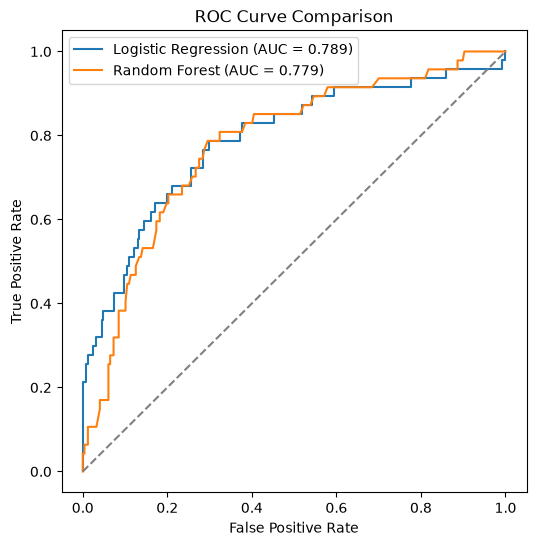

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

for name, model, X_te in [
    ("Logistic Regression", log_reg, X_test_lr),
    ("Random Forest", rf, X_test),
    
]:
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='grey')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()

### **Confusion Matrix (Best Model)**

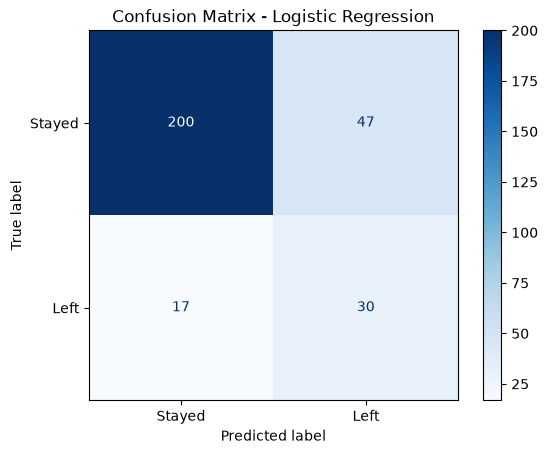

In [11]:
best_name = results_df.iloc[0]['model']
best_model, best_X = {
    'Logistic Regression': (log_reg, X_test_lr),
    'Random Forest': (rf, X_test)

}[best_name]

y_pred_best = best_model.predict(best_X)
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Left']).plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

### **Feature Importance (Tree Model)**
Cross-checking against the strong predictors flagged in EDA
(`OverTime`, `MonthlyIncome`, `Age`, `JobSatisfaction`, tenure features).

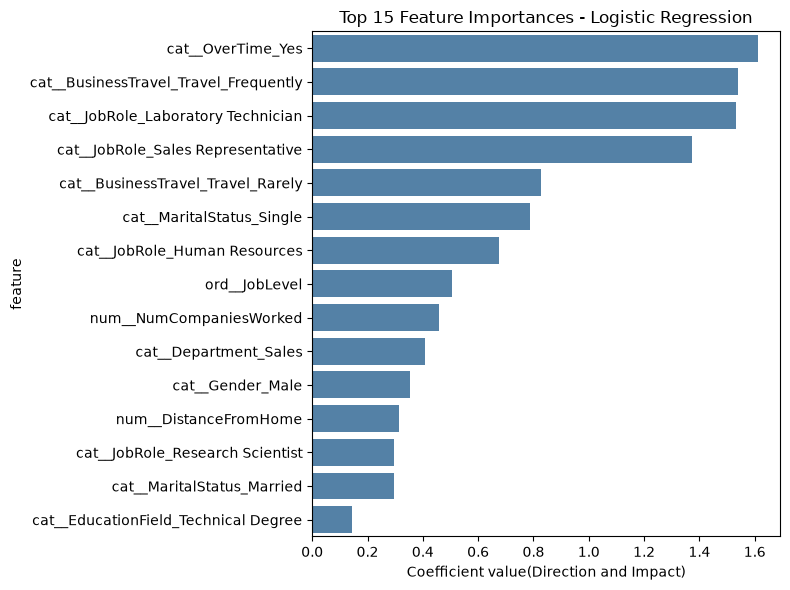

In [12]:
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
importances = best_model.named_steps['model'].coef_[0]

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=fi_df, x='importance', y='feature', color='steelblue')
plt.title(f'Top 15 Feature Importances - {best_name}')
plt.xlabel("Coefficient value(Direction and Impact)")
plt.tight_layout()
plt.show()

### **Modeling Summary**
- Data split 80/20, stratified on `Attrition` to preserve the 84/16 class ratio.
- Two models compared: Logistic Regression (baseline, multicollinear tenure features
  trimmed) and Random Forest - both using `class_weight='balanced'` to handle the
  class imbalance.
- Evaluated on ROC-AUC, PR-AUC, and per-class precision/recall/F1 rather than raw
  accuracy, since accuracy is misleading on an imbalanced target.
- **Logistic Regression was the better model**: ROC-AUC 0.789 vs 0.779, PR-AUC 0.552
  vs 0.410, and "Left"-class recall 0.64 vs 0.26.
- Feature importances from the winning model (Logistic Regression coefficients) were
  checked against the statistically-confirmed predictors from the EDA -
  `OverTime` in particular stood out as the dominant driver.